In [2]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from rasterio.windows import from_bounds, transform as window_transform
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve,
)
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rasterio.mask import mask
from rasterio.vrt import WarpedVRT
from rasterio.features import shapes
from shapely.geometry import shape
from rasterio.windows import from_bounds, Window

from pathlib import Path




### STEP 1: Binary classification of validation polygon dataset

In [3]:
# ---------------------------
# Inputs (edit these)
# ---------------------------
VALID_POLYGON = "/Users/shitong/Dropbox/myGitRepos/new/metrics_notebook/Turkiye/validation/Basarsoft_to_MicrosoftFootprints-allocations_buf15m_36WE38_37SN38.gpkg"              # geoparquet of building polygons
PTS_CLASS_COL = "ACIKLAMA"         # damage category column
BLD_ID_COL = "id"                 # unique building ID column

# Optional: define severity order (for "max severity" rule)
# SEVERITY_ORDER = [ "Destroyed (>50%)", 
#             "Major (26-50%)", "Minor (10-25%)", "Affected (1-9%)", "Inaccessible",  "No Damage"]

OUT_PQT="./Turkiye/validation/Basarsoft_to_MicrosoftFootprints_Binary.gpkg"


grading_translate_scores = {
                    "Hasarsız":                                    {"en": "Undamaged", "score":0, "cat": "Undamaged"},
                    # "Bina Kilitli İnceleme Yapılamadı (Girileme": {"en": "Unable to enter", "score":2, "cat": "Unknown"},
                    "Bina Kilitli İnceleme Yapılamadı (Girileme":  {"en": "Unable to enter", "score":2, "cat": "Unknown"},
                    "Az Hasarlı":                                  {"en": "Slightly damaged", "score":1, "cat": "Damaged"},    
                    "Ağır Hasarlı":                                {"en": "Heavily damaged",  "score":3, "cat": "Damaged"},
                    "Tespit Yapılamadı":                           {"en": "Could not detect", "score":2, "cat": "Unknown"},
                    "Acil Yıktırılacak":                           {"en": "To be demolished urgently","score":4, "cat": "Damaged"},
                    "Değerlendirme Dışı":                          {"en": "Out of scope", "score":2, "cat": "Unknown"},
                    "Yıkık":                                       {"en": "Collapsed", "score":5, "cat": "Damaged"},
                    "Tespit Edilemedi (Girilemedi)":               {"en": "Unable to enter", "score":2, "cat": "Unknown"},
                    "Kapsam Dışı":                                 {"en": "Out of scope", "score":2, "cat": "Unknown"}
                    }



In [4]:

# ---------------------------
# Load data
# ---------------------------
bld = gpd.read_file(VALID_POLYGON)


In [5]:
bld

,id,index_right,IL_ADI,ILCE_ADI,MAHALLE_AD,ACIKLAMA,Longitude,Latitude,N_Points,geometry
0,15112748,684801,Kahramanmaraş,Göksun,Ericek,Hasarsız,36.460699,37.980524,2,"POLYGON ((276986.462 4206679.292, 276972.131 4..."
1,15115152,690171,Kahramanmaraş,Onikişubat,None,Hasarsız,36.459342,37.975967,1,"POLYGON ((276847.601 4206190.18, 276850.444 42..."
2,15116864,690169,Kahramanmaraş,Onikişubat,None,Hasarsız,36.459386,37.975553,1,"POLYGON ((276843.134 4206155.534, 276841.669 4..."
3,15117322,684794,Kahramanmaraş,Göksun,Ericek,Hasarsız,36.461263,37.980369,1,"POLYGON ((277017.806 4206680.503, 277032.275 4..."
4,15126087,690167,Kahramanmaraş,Onikişubat,None,Hasarsız,36.459788,37.977376,1,"POLYGON ((276891.951 4206351.938, 276890.226 4..."
...,...,...,...,...,...,...,...,...,...,...
189170,17243638,306874,Gaziantep,Şehitkamil,Dülük,Yıkık,37.359677,37.154390,1,"POLYGON ((354342.986 4113253.139, 354334.426 4..."
189171,17243918,195881,Gaziantep,Şahinbey,Barış,Yıkık,37.394381,37.052597,2,"POLYGON ((357218.605 4101908.232, 357230.302 4..."
189172,17244837,319776,Gaziantep,Şehitkamil,Hacıbaba,Yıkık,37.391294,37.078475,1,"POLYGON ((357011.838 4104792.837, 357020.172 4..."
189173,17271271,18181,Adıyaman,Besni,Kutluca,Yıkık,37.975848,37.595965,101,"POLYGON ((409606.459 4161491.209, 409606.697 4..."


In [6]:

# Map each building to Damaged / Undamaged

bld["damage_class"] = bld["ACIKLAMA"].apply(
    lambda x: grading_translate_scores[x]["en"] if x in grading_translate_scores.keys() else "Unknown"
)

bld["damage_binary"] = bld["ACIKLAMA"].apply(
    lambda x: grading_translate_scores[x]["cat"] if x in grading_translate_scores.keys() else "Unknown"
)

bld["damage_score"] = bld["ACIKLAMA"].apply(
    lambda x: grading_translate_scores[x]["score"] if x in grading_translate_scores.keys() else nan
)


bld_out = bld[bld["damage_binary"] != "Unknown"]

# bld_out is currently EPSG:4326 (lat/lon)
bld_m = bld_out.to_crs(bld_out.estimate_utm_crs())  # meters
bld_m["area_m2"] = bld_m.geometry.area

# # If you want the area back on the original lat/lon dataframe:
bld_out["area_m2"] = bld_m["area_m2"].values
bld_out.to_file(OUT_PQT)

/Users/shitong/miniforge3/envs/isce3/lib/python3.12/site-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [7]:
bld_out

,id,index_right,IL_ADI,ILCE_ADI,MAHALLE_AD,ACIKLAMA,Longitude,Latitude,N_Points,geometry,damage_class,damage_binary,damage_score,area_m2
0,15112748,684801,Kahramanmaraş,Göksun,Ericek,Hasarsız,36.460699,37.980524,2,"POLYGON ((276986.462 4206679.292, 276972.131 4...",Undamaged,Undamaged,0,185.757819
1,15115152,690171,Kahramanmaraş,Onikişubat,None,Hasarsız,36.459342,37.975967,1,"POLYGON ((276847.601 4206190.18, 276850.444 42...",Undamaged,Undamaged,0,139.466635
2,15116864,690169,Kahramanmaraş,Onikişubat,None,Hasarsız,36.459386,37.975553,1,"POLYGON ((276843.134 4206155.534, 276841.669 4...",Undamaged,Undamaged,0,26.936526
3,15117322,684794,Kahramanmaraş,Göksun,Ericek,Hasarsız,36.461263,37.980369,1,"POLYGON ((277017.806 4206680.503, 277032.275 4...",Undamaged,Undamaged,0,208.535283
4,15126087,690167,Kahramanmaraş,Onikişubat,None,Hasarsız,36.459788,37.977376,1,"POLYGON ((276891.951 4206351.938, 276890.226 4...",Undamaged,Undamaged,0,114.497194
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189170,17243638,306874,Gaziantep,Şehitkamil,Dülük,Yıkık,37.359677,37.154390,1,"POLYGON ((354342.986 4113253.139, 354334.426 4...",Collapsed,Damaged,5,127.031432
189171,17243918,195881,Gaziantep,Şahinbey,Barış,Yıkık,37.394381,37.052597,2,"POLYGON ((357218.605 4101908.232, 357230.302 4...",Collapsed,Damaged,5,79.512910
189172,17244837,319776,Gaziantep,Şehitkamil,Hacıbaba,Yıkık,37.391294,37.078475,1,"POLYGON ((357011.838 4104792.837, 357020.172 4...",Collapsed,Damaged,5,37.578808
189173,17271271,18181,Adıyaman,Besni,Kutluca,Yıkık,37.975848,37.595965,101,"POLYGON ((409606.459 4161491.209, 409606.697 4...",Collapsed,Damaged,5,270.363903


In [8]:
### Check Category Balance over all classes
metrics = (
    bld_out.groupby("damage_class")
    .agg(num_buildings=("damage_class","count"),
         total_area_m2=("area_m2","sum"))
)
metrics["pct_area"] = (
    metrics["total_area_m2"] / metrics["total_area_m2"].sum() * 100
).round(2)
print(metrics)

### Check Category Balance over binary classes
metrics = (
    bld_out.groupby("damage_binary")
    .agg(num_buildings=("damage_binary","count"),
         total_area_m2=("area_m2","sum"))
)

metrics["pct_area"] = (
    metrics["total_area_m2"] / metrics["total_area_m2"].sum() * 100
).round(2)

print(metrics)

                           num_buildings  total_area_m2  pct_area
damage_class                                                     
Collapsed                           4226   1.308943e+06      3.03
Heavily damaged                    14932   4.501626e+06     10.40
Slightly damaged                   44927   1.464432e+07     33.85
To be demolished urgently           2699   8.168800e+05      1.89
Undamaged                          89921   2.199265e+07     50.83
               num_buildings  total_area_m2  pct_area
damage_binary                                        
Damaged                66784   2.127177e+07     49.17
Undamaged              89921   2.199265e+07     50.83


### STEP 2: Merging Building Footprint and DPM2 raster

In [9]:
# Configuration
target_raster_paths = [
    "Turkiye/TD021/20230210.wprobs.geo.tif",
    "Turkiye/TD021/20230210_ele.wprobs.geo.tif",    
]

# DAMAGE_RASTER = target_raster_paths[0]# Input TIFF file
# BBOX = 
# RASTER_THRESHOLD = 0.78          # Pixel threshold (0-1)
AREA_FRACTION_THRESHOLD = 0.3  # Set the threshold for intersection percentage (e.g., 25%)
# # If the intersection area is greater than 25% of the building area, it will be considered as intersecting.
# CLUSTER_DISTANCE = 75

INPUT_GEO_PARQUET_FILE = OUT_PQT
OUT_GPQ="./Turkiye/validation/TD021_Basarsoft_to_MicrosoftFootprints_Binary_Raster.parquet"# "building_footprints.parquet"


In [10]:
# bld = gpd.read_parquet(INPUT_GEO_PARQUET_FILE)

# # Fix invalid polygons (common)
# bld["geometry"] = bld.geometry.buffer(0)
# utm_crs = bld.estimate_utm_crs()
# bld_m = bld.to_crs(utm_crs)

In [11]:
# with rasterio.open(DAMAGE_RASTER) as src:
#     with WarpedVRT(src, crs=utm_crs) as src_m:
#         data = src_m.read(1)

#         nodata = src_m.nodata
#         valid = np.isfinite(data)
#         if nodata is not None:
#             valid &= (data != nodata)

#         damaged_mask = valid & (data >= RASTER_THRESHOLD)

#         # Polygonize ONLY damaged pixels (each polygon is a set of grid cells)
#         # Note: shapes() will merge adjacent pixels with same value; that’s fine.
#         geoms = []
#         for geom, val in shapes(
#             data.astype(np.float32),
#             mask=damaged_mask,
#             transform=src_m.transform
#         ):
#             geoms.append(shape(geom))

# damaged_grid = gpd.GeoDataFrame({"geometry": geoms}, crs=utm_crs)

# # (Optional) explode multipart polygons for faster overlay
# damaged_grid = damaged_grid.explode(index_parts=False).reset_index(drop=True)

# # -----------------------------
# # Exact overlap: intersect damaged grid polygons with buildings
# # -----------------------------
# # Use overlay (exact geometry intersection)
# inter = gpd.overlay(
#     bld_m[["id", "area_m2", "geometry"]],
#     damaged_grid[["geometry"]],
#     how="intersection",
#     keep_geom_type=True
# )

# # Overlap area in m2 (exact)
# inter["overlap_m2"] = inter.geometry.area

# # Sum overlap area per building
# overlap_by_bld = (
#     inter.groupby("id", as_index=False)["overlap_m2"]
#     .sum()
#     .rename(columns={"overlap_m2": "damage_area_m2_map"})
# )

# # Attach back to buildings
# bld_m = bld_m.merge(overlap_by_bld, on="id", how="left")
# # bld_m["damage_area_m2_map"] = bld_m["damage_area_m2_map"].fillna(0.0)

# # Fraction damaged by area
# bld_m["damage_frac_map"] = bld_m["damage_area_m2_map"] / bld_m["area_m2"]

# # Binary label
# bld_m["damage_binary_map"] = np.where(
#     bld_m["damage_frac_map"] >= AREA_FRACTION_THRESHOLD,
#     "Damaged",
#     "Undamaged"
# )

# # -----------------------------
# # Save (back to original CRS if you want)
# # -----------------------------
# bld_out = bld_m.to_crs(bld.crs)

# bld_out.to_parquet(OUT_GPQ, index=False)
# print(bld_out["damage_binary_map"].value_counts(dropna=False))

In [12]:
# bld_out.head()

#### METRICS

In [13]:
# def accuracy(TP, FP, FN, TN):
#     return (TP + TN) / (TP + FP + FN + TN)

# def f1(TP, FP, FN):
#     return (2 * TP) / (2 * TP + FP + FN)

# def csi(TP, FP, FN):
#     return TP / (TP + FP + FN)

In [14]:
# import numpy as np
# import pandas as pd

# GT_COL   = "damage_binary_gnd"
# PRED_COL = "damage_binary_map"
# AREA_COL = "area_m2"

# # Keep valid rows only
# df = bld_out[[GT_COL, PRED_COL, AREA_COL]].dropna()

# allowed = {"Damaged", "Undamaged"}
# df = df[
#     df[GT_COL].isin(allowed) &
#     df[PRED_COL].isin(allowed) &
#     (df[AREA_COL] > 0)
# ].copy()

# # Binary encoding
# df["y_true"] = (df[GT_COL] == "Damaged").astype(int)
# df["y_pred"] = (df[PRED_COL] == "Damaged").astype(int)

In [15]:
# TP_c = ((df.y_true == 1) & (df.y_pred == 1)).sum()
# FP_c = ((df.y_true == 0) & (df.y_pred == 1)).sum()
# FN_c = ((df.y_true == 1) & (df.y_pred == 0)).sum()
# TN_c = ((df.y_true == 0) & (df.y_pred == 0)).sum()

# TP_a = df.loc[(df.y_true == 1) & (df.y_pred == 1), AREA_COL].sum()
# FP_a = df.loc[(df.y_true == 0) & (df.y_pred == 1), AREA_COL].sum()
# FN_a = df.loc[(df.y_true == 1) & (df.y_pred == 0), AREA_COL].sum()
# TN_a = df.loc[(df.y_true == 0) & (df.y_pred == 0), AREA_COL].sum()


In [16]:
# metrics = pd.DataFrame({
#     "Metric": ["Accuracy", "F1", "CSI"],
#     "Non_area_weighted": [
#         accuracy(TP_c, FP_c, FN_c, TN_c),
#         f1(TP_c, FP_c, FN_c),
#         csi(TP_c, FP_c, FN_c),
#     ],
#     "Area_weighted": [
#         accuracy(TP_a, FP_a, FN_a, TN_a),
#         f1(TP_a, FP_a, FN_a),
#         csi(TP_a, FP_a, FN_a),
#     ],
# })

# print(metrics.round(4))

#### DO THE SWEEP

In [17]:
GT_COL = "damage_binary"     # ground truth: "Damaged"/"Undamaged"
ID_COL = "id"                    # building id
AREA_COL = "area_m2"             # building area (m2)
AREA_FRAC_THRESHOLD = 0.30       # building damaged if >=30% area is damaged
THRESHOLDS = np.round(np.arange(0.5, 1.0 + 1e-9, 0.02), 2)

ALLOWED = {"Damaged", "Undamaged"}

def metrics_from_confusion(TP, FP, FN, TN):
    acc = (TP + TN) / (TP + FP + FN + TN) if (TP + FP + FN + TN) > 0 else np.nan
    f1  = (2 * TP) / (2 * TP + FP + FN)   if (2 * TP + FP + FN) > 0 else np.nan
    csi = TP / (TP + FP + FN)             if (TP + FP + FN) > 0 else np.nan
    return acc, f1, csi

def compute_pixel_overlap_table(bld_gdf, raster_path, band=1):
    """
    Returns:
      bld_m: buildings in UTM with area_m2
      ov: DataFrame with columns [id, value, overlap_m2]
    """
    #filenames
    raster_base = Path(raster_path).stem
    bld_m_file=f"Turkiye/validation_overlap/{raster_base}_bldm.gpkg"
    ov_file=f"Turkiye/validation_overlap/{raster_base}_ov.csv"

    if os.path.exists(bld_m_file) and os.path.exists(ov_file):
        print("Loading cached overlap results...")
        bld_m = gpd.read_file(bld_m_file)
        ov = pd.read_csv(ov_file)
        return bld_m, ov

    
    # Reproject buildings to UTM meters
    utm_crs = bld_gdf.estimate_utm_crs()
    bld_m = bld_gdf.to_crs(utm_crs).copy()
    bld_m["geometry"] = bld_m.geometry.buffer(0)
    bld_m[AREA_COL] = bld_m.geometry.area
    print(f"computing overlaps of raster with building fp:{raster_path}")

    with rasterio.open(raster_path) as src:
        with WarpedVRT(src, crs=utm_crs) as src_m:
            nodata = src_m.nodata

            # ---- STEP 6: crop raster read to building extent (in UTM, same as src_m)
            minx, miny, maxx, maxy = bld_m.total_bounds
            print(f"{ bld_m.total_bounds}, {src_m.bounds}")
            
            # Make a window covering those bounds (clamped to raster)
            win = from_bounds(minx, miny, maxx, maxy, transform=src_m.transform)
            
            # Intersect with dataset window to avoid out-of-range reads
            full = Window(0, 0, src_m.width, src_m.height)
            win = win.intersection(full)
            
            # Read only that window (also avoids an extra copy vs .astype)
            arr = src_m.read(band, window=win, out_dtype="float32")
            
            # Window-specific transform is REQUIRED for correct geometry locations
            win_transform = src_m.window_transform(win)
            
            valid = np.isfinite(arr)
            if nodata is not None:
                valid &= (arr != nodata)
            
            # Polygonize only the cropped region
            geoms, vals = [], []
            for geom, val in shapes(arr, mask=valid, transform=win_transform):
                geoms.append(shape(geom))
                vals.append(float(val))
    
                

    print(f"grid dataframe")
    grid = gpd.GeoDataFrame({"value": vals, "geometry": geoms}, crs=utm_crs)

    # Intersect once
    inter = gpd.overlay(
        bld_m[[ID_COL, AREA_COL, "geometry"]],
        grid[["value", "geometry"]],
        how="intersection",
        keep_geom_type=True,
    )
    inter["overlap_m2"] = inter.geometry.area

    ov = inter[[ID_COL, "value", "overlap_m2"]].copy()
    bld_m.to_file(bld_m_file, driver="GPKG")
    ov.to_csv(ov_file)
    return bld_m, ov

def sweep_thresholds(bld_m, ov, raster_path, thresholds=THRESHOLDS):
    """
    Compute non-area-weighted + area-weighted Accuracy/F1/CSI for each threshold.
    """
    # Ground truth
    base = bld_m.dropna().copy()
    base = base[base[GT_COL].isin(ALLOWED) & (base[AREA_COL] > 0)].copy()
    base["y_true"] = (base[GT_COL] == "Damaged").astype(int)

    # Attach overlaps only for buildings in base
    ov2 = ov[ov[ID_COL].isin(base[ID_COL])].copy()

    rows = []
    # Pre-sort overlaps by value to speed filtering
    ov2 = ov2.sort_values("value")

    for t in thresholds:
        print(f"threshold: {t}")
        # damaged area per building = sum overlap where value >= t
        dmg_area = (
            ov2.loc[ov2["value"] >= t]
            .groupby(ID_COL)["overlap_m2"]
            .sum()
            .rename("damage_area_m2")
        )

        df = base.merge(dmg_area, on=ID_COL, how="left")
        df["damage_area_m2"] = df["damage_area_m2"].fillna(0.0)
        df["damage_frac"] = df["damage_area_m2"] / df[AREA_COL]
        df["y_pred"] = (df["damage_frac"] >= AREA_FRAC_THRESHOLD).astype(int)

        # ---- Non-area-weighted confusion (counts)
        TP_c = ((df.y_true == 1) & (df.y_pred == 1)).sum()
        FP_c = ((df.y_true == 0) & (df.y_pred == 1)).sum()
        FN_c = ((df.y_true == 1) & (df.y_pred == 0)).sum()
        TN_c = ((df.y_true == 0) & (df.y_pred == 0)).sum()

        acc_c, f1_c, csi_c = metrics_from_confusion(TP_c, FP_c, FN_c, TN_c)

        # ---- Area-weighted confusion (sum of areas)
        TP_a = df.loc[(df.y_true == 1) & (df.y_pred == 1), AREA_COL].sum()
        FP_a = df.loc[(df.y_true == 0) & (df.y_pred == 1), AREA_COL].sum()
        FN_a = df.loc[(df.y_true == 1) & (df.y_pred == 0), AREA_COL].sum()
        TN_a = df.loc[(df.y_true == 0) & (df.y_pred == 0), AREA_COL].sum()

        acc_a, f1_a, csi_a = metrics_from_confusion(TP_a, FP_a, FN_a, TN_a)

        rows.append({
            "threshold": t,
            "acc_count": acc_c, "f1_count": f1_c, "csi_count": csi_c,
            "acc_area":  acc_a, "f1_area":  f1_a, "csi_area":  csi_a,
            "TP_count": TP_c, "FP_count": FP_c, "FN_count": FN_c, "TN_count": TN_c,
        })
        raster_base = Path(raster_path).stem
        # df = df.merge(bld_m[[ID_COL, "geometry"]],on=ID_COL,how="left")
        # gdf_out = gpd.GeoDataFrame(df, geometry="geometry", crs=bld_m.crs)
        df.to_file(f"Turkiye/thresholded/{raster_base}_t{t}.gpkg", driver="GPKG")
        del df

    return pd.DataFrame(rows)



In [18]:
def _fix_geom(g):
    # buffer(0) is common; make_valid is safer (shapely>=2)
    if g is None or g.is_empty:
        return g
    try:
        g2 = make_valid(g)
    except Exception:
        g2 = g.buffer(0)
    return g2

def _pixel_polygon(transform, row, col):
    """
    Returns a shapely Polygon for the pixel (row, col) using the raster transform.
    Works even if transform has rotation.
    """
    # corners in (col,row) coordinates
    x0, y0 = transform * (col,     row)
    x1, y1 = transform * (col + 1, row)
    x2, y2 = transform * (col + 1, row + 1)
    x3, y3 = transform * (col,     row + 1)
    return Polygon([(x0, y0), (x1, y1), (x2, y2), (x3, y3)])

def compute_pixel_overlap_table_A2(bld_gdf, raster_path, band=1, window_pad=1):
    """
    Exact fractional overlap, but computed locally per-building (no global polygonize).

    Returns:
      bld_m: buildings in UTM with area_m2
      ov: DataFrame with columns [id, value, overlap_m2]
    """
    # Reproject buildings to UTM meters
    utm_crs = bld_gdf.estimate_utm_crs()
    bld_m = bld_gdf.to_crs(utm_crs).copy()

    # Clean geometry + area
    bld_m["geometry"] = bld_m.geometry.apply(_fix_geom)
    bld_m = bld_m[~bld_m.geometry.is_empty & bld_m.geometry.notna()].copy()
    bld_m[AREA_COL] = bld_m.geometry.area

    print(f"computing exact overlaps (local windows) for raster: {raster_path}")

    out_ids = []
    out_vals = []
    out_areas = []

    with rasterio.open(raster_path) as src:
        # Warp raster into the same UTM CRS as buildings
        with WarpedVRT(src, crs=utm_crs) as src_m:
            nodata = src_m.nodata

            # Loop buildings; each building touches only a handful of 30m pixels
            for bid, geom in zip(bld_m[ID_COL].values, bld_m.geometry.values):
                if geom is None or geom.is_empty:
                    continue

                # Compute minimal raster window covering this building (+small pad)
                try:
                    win = geometry_window(src_m, [geom], pad_x=window_pad, pad_y=window_pad, north_up=True)
                except Exception:
                    # If geometry is outside raster extent or window can't be computed
                    continue

                if win.width <= 0 or win.height <= 0:
                    continue

                # Read just this window
                arr = src_m.read(band, window=win)
                # Window transform: pixel->map for this window
                wtransform = src_m.window_transform(win)

                # Valid mask
                valid = np.isfinite(arr)
                if nodata is not None:
                    valid &= (arr != nodata)

                if not np.any(valid):
                    continue

                # Prepared geometry speeds up repeated intersects
                pgeom = prep(geom)

                # Iterate only valid pixels in window
                rows, cols = np.where(valid)
                for r, c in zip(rows.tolist(), cols.tolist()):
                    val = float(arr[r, c])

                    pix_poly = _pixel_polygon(wtransform, r, c)

                    # Quick reject then exact intersection area
                    if not pgeom.intersects(pix_poly):
                        continue

                    inter = geom.intersection(pix_poly)
                    if inter.is_empty:
                        continue

                    a = float(inter.area)
                    if a <= 0:
                        continue

                    out_ids.append(bid)
                    out_vals.append(val)
                    out_areas.append(a)

    ov = pd.DataFrame({ID_COL: out_ids, "value": out_vals, "overlap_m2": out_areas})
    return bld_m, ov

In [19]:
# -----------------------------
# Main: multiple rasters
# -----------------------------
def threshold_sweep_multiple_rasters(bld_out, raster_paths):
    results = []
    for rp in raster_paths:
        print(f"raster: {rp}")
        bld_m, ov = compute_pixel_overlap_table(bld_out, rp, band=1)
        df_metrics = sweep_thresholds(bld_m, ov, rp, thresholds=THRESHOLDS)
        df_metrics["raster"] = rp
        results.append(df_metrics)

    return pd.concat(results, ignore_index=True)


In [20]:
# target_raster_paths = [
#     "TA64_LA_Wildfires/others/20250109.wprobs.geo.masked.tif",
#     "TA64_LA_Wildfires/others/20250109.wprobs.geo.tif",
#     # "TA64_LA_Wildfires/others/geo_20250109_mpy_linear.wprobs.tif",
#     "TA64_LA_Wildfires/others/geo_20250109_mpy_br500_linear.masked.wprobs.tif",
#     "TA64_LA_Wildfires/others/geo_20250109_mpy_br500_linear.wprobs.tif",
#     # "TA64_LA_Wildfires/others/geo_20250109_mpy_nn.wprobs.tif",
#     # "TA64_LA_Wildfires/others/geoisce_nn_220250109.wprobs.geo.tif",
#     "TA64_LA_Wildfires/others/geoisce_linear_20250109.wprobs.masked.geo.tif",
#     "TA64_LA_Wildfires/others/geoisce_linear_20250109.wprobs.geo.tif",
#     # "TA64_LA_Wildfires/others/geoisce_sinc_20250109.wprobs.geo.tif",
#     "TA64_LA_Wildfires/20250109_GSLC_30m_resampled.wprobs.geo.tif"
# ]
sweep_df = threshold_sweep_multiple_rasters(bld_out, target_raster_paths)
sweep_df.to_csv("threshold_sweep_metrics_turkiye.csv", index=False)

raster: Turkiye/TD021/20230210.wprobs.geo.tif
Loading cached overlap results...
threshold: 0.5
threshold: 0.52
threshold: 0.54
threshold: 0.56
threshold: 0.58
threshold: 0.6
threshold: 0.62
threshold: 0.64
threshold: 0.66
threshold: 0.68
threshold: 0.7
threshold: 0.72
threshold: 0.74
threshold: 0.76
threshold: 0.78
threshold: 0.8
threshold: 0.82
threshold: 0.84
threshold: 0.86
threshold: 0.88
threshold: 0.9
threshold: 0.92
threshold: 0.94
threshold: 0.96
threshold: 0.98
threshold: 1.0
raster: Turkiye/TD021/20230210_ele.wprobs.geo.tif
computing overlaps of raster with building fp:Turkiye/TD021/20230210_ele.wprobs.geo.tif
[ 234546.67798497 4095544.77476542  411330.25394089 4206710.69512634], BoundingBox(left=253501.0754658273, bottom=3918049.867102302, right=504255.5320725561, top=4308843.464050153)
grid dataframe
threshold: 0.5
threshold: 0.52
threshold: 0.54
threshold: 0.56
threshold: 0.58
threshold: 0.6
threshold: 0.62
threshold: 0.64
threshold: 0.66
threshold: 0.68
threshold: 0.7
thr

In [21]:
sweep_df.sort_values(["raster", "threshold"]).head(30)

,threshold,acc_count,f1_count,csi_count,acc_area,f1_area,csi_area,TP_count,FP_count,FN_count,TN_count,raster
0,0.50,0.557812,0.609843,0.438687,0.535031,0.640618,0.471257,54155,56664,12629,33257,Turkiye/TD021/20230210.wprobs.geo.tif
1,0.52,0.570773,0.608377,0.437171,0.539259,0.635313,0.465537,52245,52723,14539,37198,Turkiye/TD021/20230210.wprobs.geo.tif
2,0.54,0.582272,0.605463,0.434168,0.542844,0.628814,0.458592,50228,48904,16556,41017,Turkiye/TD021/20230210.wprobs.geo.tif
3,0.56,0.594008,0.602773,0.431407,0.548898,0.623115,0.452554,48271,45108,18513,44813,Turkiye/TD021/20230210.wprobs.geo.tif
4,0.58,0.604863,0.599140,0.427695,0.551948,0.615191,0.444243,46274,41410,20510,48511,Turkiye/TD021/20230210.wprobs.geo.tif
5,0.60,0.614275,0.594092,0.422568,0.557282,0.608650,0.437453,44234,37895,22550,52026,Turkiye/TD021/20230210.wprobs.geo.tif
6,0.62,0.622737,0.588110,0.416541,0.561617,0.601359,0.429959,42206,34541,24578,55380,Turkiye/TD021/20230210.wprobs.geo.tif
7,0.64,0.629942,0.580670,0.409115,0.566327,0.592941,0.421405,40151,31357,26633,58564,Turkiye/TD021/20230210.wprobs.geo.tif
8,0.66,0.634989,0.571154,0.399731,0.563603,0.573797,0.402325,38090,28505,28694,61416,Turkiye/TD021/20230210.wprobs.geo.tif
9,0.68,0.639533,0.560703,0.389567,0.567430,0.562852,0.391645,36049,25752,30735,64169,Turkiye/TD021/20230210.wprobs.geo.tif


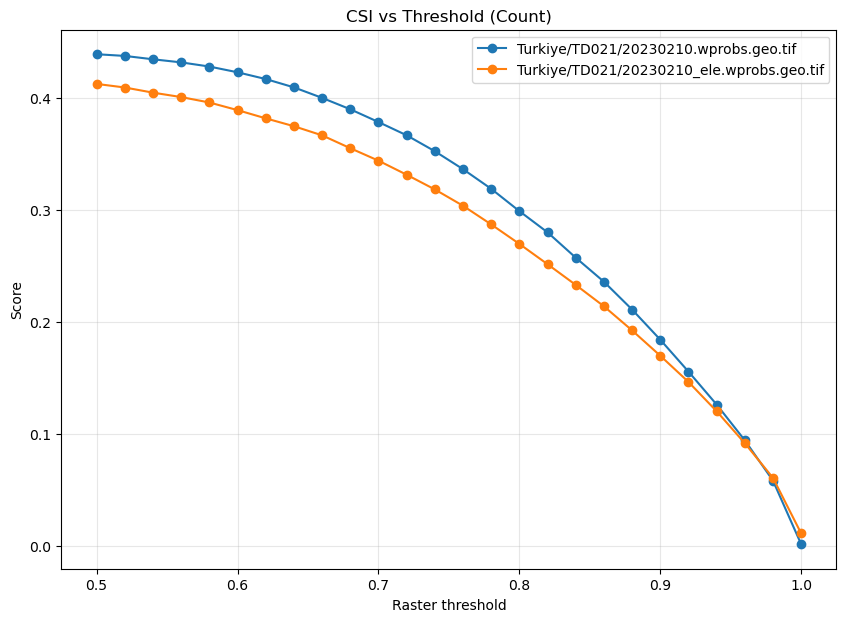

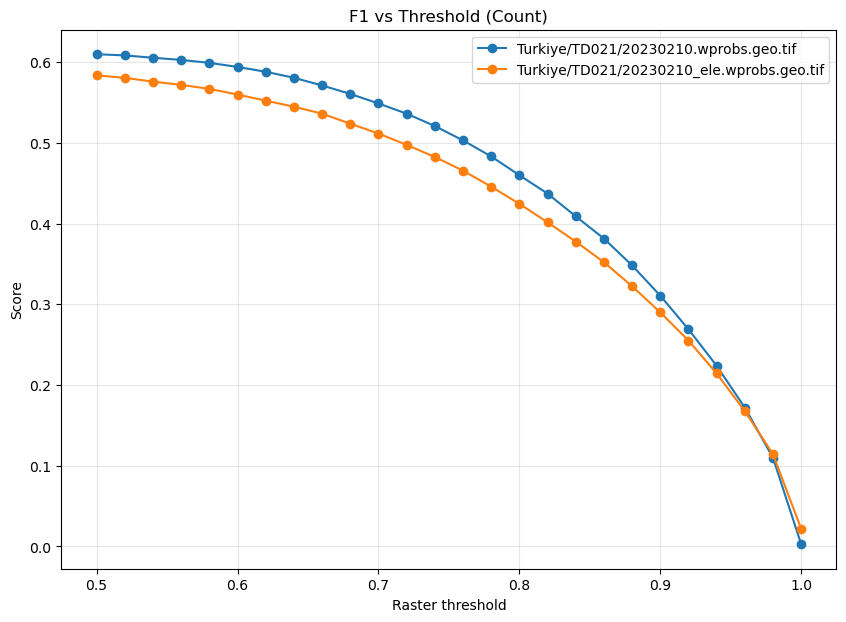

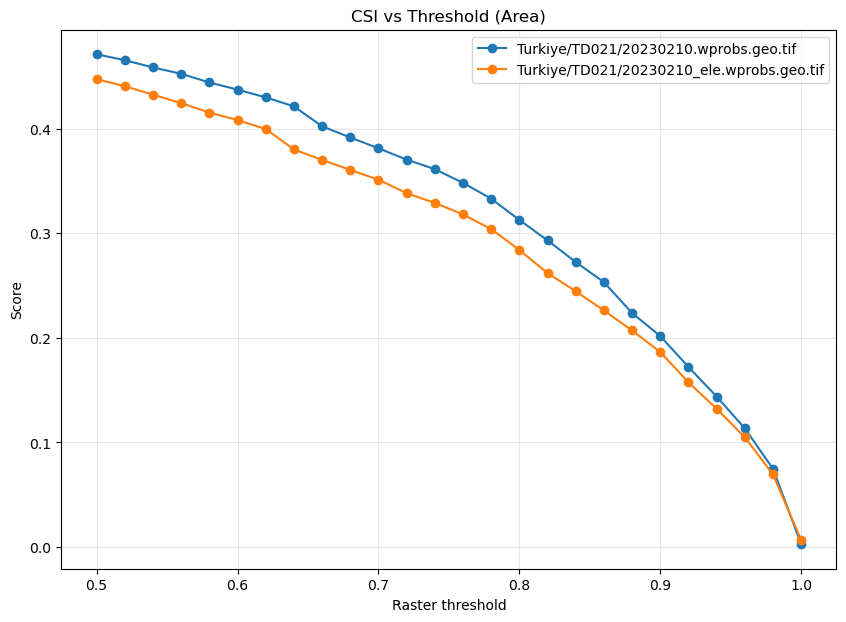

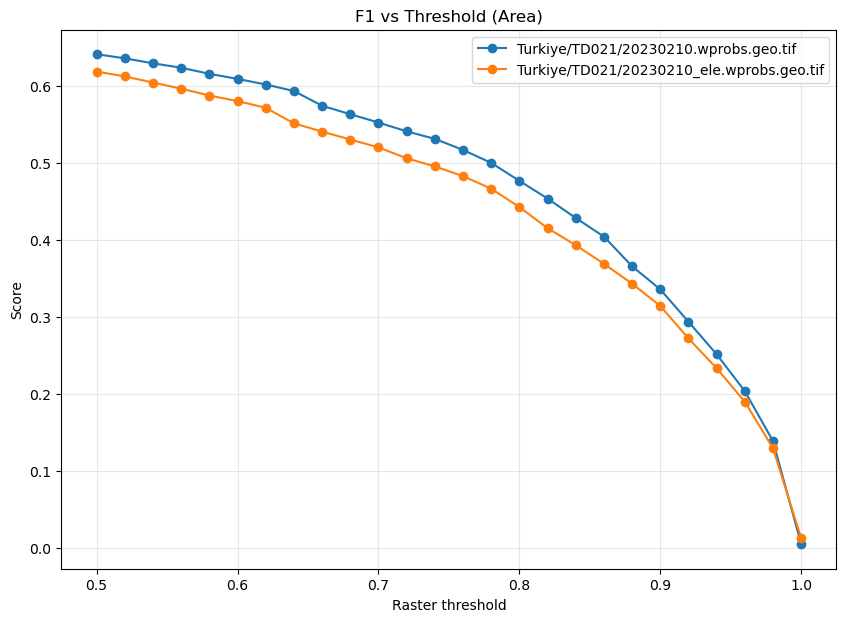

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_all_rasters_threshold_sweep(sweep_df):
    # Ensure sorted thresholds within each raster
    grouped = {
        r: df.sort_values("threshold")
        for r, df in sweep_df.groupby("raster")
    }

    plots = [
        ("csi_count", "CSI vs Threshold (Count)"),
        ("f1_count",  "F1 vs Threshold (Count)"),
        ("csi_area",  "CSI vs Threshold (Area)"),
        ("f1_area",   "F1 vs Threshold (Area)"),
    ]

    for col, title in plots:
        plt.figure(figsize=(10,7))
        for raster_name, df_r in grouped.items():
            plt.plot(df_r["threshold"], df_r[col], marker="o", label=str(raster_name))
        plt.xlabel("Raster threshold")
        plt.ylabel("Score")
        # plt.ylim(*(0.65, 0.88))   # <-- limit x-axis
        plt.title(title)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()


# Usage:
sweep_df=pd.read_csv("threshold_sweep_metrics_turkiye.csv")

# sweep_df = gpd.GeoDataFrame(
#     sweep_df,
#     geometry=gpd.points_from_xy(sweep_df.longitude, sweep_df.latitude),
#     crs="EPSG:4326"
# )
plot_all_rasters_threshold_sweep(sweep_df)
